# BailMitra — Risk Assessment Model Training

This notebook trains and compares several classifiers on `dummy_criminal_risk_dataset.csv`
(50,000 rows, 20 features) to predict a defendant's **Risk_Category** (Low / Medium / High),
and saves the best-performing model as `risk_prediction_model.pkl` for use by the BailMitra
prediction pipeline (`bailmitra.ipynb`).

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from xgboost import XGBClassifier

pd.set_option("display.max_columns", 25)
RANDOM_STATE = 42

## 1. Load the dataset

In [2]:
df = pd.read_csv("dummy_criminal_risk_dataset.csv")
print(df.shape)
df.head()

(50000, 21)


,Case_ID,Age,Gender,Prior_Arrests,Prior_Convictions,Offense_Severity,Charge_Type,Bail_History,Flight_Risk,Employment_Status,Community_Ties,Weapon_Used,Violence_Involved,Evidence_Strength,Victim_Impact,Repeat_Offender,Substance_Abuse_History,Mental_Health_Concern,Court_Appearance_History,Risk_Category,Bail_Granted
0,CR100000,37,Male,2,2,Moderate,Petty Offense,Bail Granted - Complied,Low,Unemployed,Strong,No,No,Strong,Minor,Yes,No,No,Always Appeared,Medium,No
1,CR100001,30,Male,0,0,Minor,Felony,Minor Violation,Medium,Unemployed,Weak,No,No,Strong,Severe,No,No,No,Always Appeared,Low,Yes
2,CR100002,39,Female,3,1,Minor,Petty Offense,Bail Granted - Complied,Low,Student,Moderate,No,No,Weak,Severe,No,No,No,Always Appeared,Low,Yes
3,CR100003,48,Female,1,0,Moderate,Petty Offense,Bail Violated,Low,Employed,Strong,No,No,Strong,No Impact,No,No,No,Always Appeared,Low,Yes
4,CR100004,29,Male,2,0,Moderate,Felony,No Prior Bail,Low,Self-Employed,Strong,No,Yes,Moderate,Minor,No,No,No,Missed Once,Low,No


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 21 columns):
 #   Column                    Non-Null Count  Dtype
---  ------                    --------------  -----
 0   Case_ID                   50000 non-null  str  
 1   Age                       50000 non-null  int64
 2   Gender                    50000 non-null  str  
 3   Prior_Arrests             50000 non-null  int64
 4   Prior_Convictions         50000 non-null  int64
 5   Offense_Severity          50000 non-null  str  
 6   Charge_Type               50000 non-null  str  
 7   Bail_History              50000 non-null  str  
 8   Flight_Risk               50000 non-null  str  
 9   Employment_Status         50000 non-null  str  
 10  Community_Ties            50000 non-null  str  
 11  Weapon_Used               50000 non-null  str  
 12  Violence_Involved         50000 non-null  str  
 13  Evidence_Strength         50000 non-null  str  
 14  Victim_Impact             50000 non-null  str  
 

In [4]:
df["Risk_Category"].value_counts()

Risk_Category
Low       27500
Medium    15000
High       7500
Name: count, dtype: int64

## 2. Exploratory look at class balance

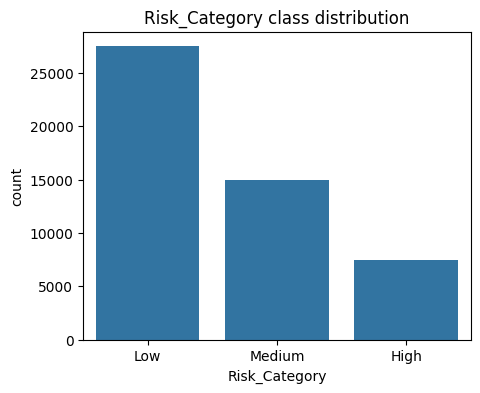

In [5]:
plt.figure(figsize=(5, 4))
sns.countplot(x=df["Risk_Category"], order=["Low", "Medium", "High"])
plt.title("Risk_Category class distribution")
plt.show()

## 3. Encode categorical features

All 20 predictive features are used except the identifier column (`Case_ID`) and the
secondary target (`Bail_Granted`), which is kept aside for a separate downstream analysis.

In [6]:
categorical_columns = [
    "Gender", "Offense_Severity", "Charge_Type", "Bail_History", "Flight_Risk",
    "Employment_Status", "Community_Ties", "Weapon_Used", "Violence_Involved",
    "Evidence_Strength", "Victim_Impact", "Repeat_Offender",
    "Substance_Abuse_History", "Mental_Health_Concern", "Court_Appearance_History",
]

label_encoders = {}
df_enc = df.copy()
for col in categorical_columns:
    le = LabelEncoder()
    df_enc[col] = le.fit_transform(df_enc[col])
    label_encoders[col] = le

target_encoder = LabelEncoder()
df_enc["Risk_Category_encoded"] = target_encoder.fit_transform(df_enc["Risk_Category"])
print(dict(zip(target_encoder.classes_, target_encoder.transform(target_encoder.classes_))))

{'High': np.int64(0), 'Low': np.int64(1), 'Medium': np.int64(2)}


## 4. Train / test split and feature scaling

In [7]:
feature_cols = [
    "Age", "Gender", "Prior_Arrests", "Prior_Convictions", "Offense_Severity",
    "Charge_Type", "Bail_History", "Flight_Risk", "Employment_Status",
    "Community_Ties", "Weapon_Used", "Violence_Involved", "Evidence_Strength",
    "Victim_Impact", "Repeat_Offender", "Substance_Abuse_History",
    "Mental_Health_Concern", "Court_Appearance_History",
]

X = df_enc[feature_cols]
y = df_enc["Risk_Category_encoded"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

X_train.shape, X_test.shape

((40000, 18), (10000, 18))

## 5. Model 1 — Logistic Regression (baseline)

In [8]:
log_reg = LogisticRegression(solver="lbfgs", max_iter=1000)  # multinomial handling is automatic for >2 classes
log_reg.fit(X_train_scaled, y_train)

y_pred_lr = log_reg.predict(X_test_scaled)
print(f"Logistic Regression Accuracy: {accuracy_score(y_test, y_pred_lr):.3f}")
print(classification_report(y_test, y_pred_lr, target_names=target_encoder.classes_))

Logistic Regression Accuracy: 0.671
              precision    recall  f1-score   support

        High       0.64      0.46      0.53      1500
         Low       0.75      0.87      0.80      5500
      Medium       0.49      0.42      0.45      3000

    accuracy                           0.67     10000
   macro avg       0.63      0.58      0.60     10000
weighted avg       0.66      0.67      0.66     10000



## 6. Model 2 — Random Forest Classifier

In [9]:
rf_model = RandomForestClassifier(
    n_estimators=150, max_depth=12, min_samples_leaf=5,
    random_state=RANDOM_STATE, n_jobs=-1
)
rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)
rf_accuracy = accuracy_score(y_test, y_pred_rf)
print(f"Random Forest Accuracy: {rf_accuracy:.3f}")
print(classification_report(y_test, y_pred_rf, target_names=target_encoder.classes_))

Random Forest Accuracy: 0.719
              precision    recall  f1-score   support

        High       0.73      0.51      0.60      1500
         Low       0.78      0.90      0.84      5500
      Medium       0.56      0.49      0.52      3000

    accuracy                           0.72     10000
   macro avg       0.69      0.63      0.65     10000
weighted avg       0.71      0.72      0.71     10000



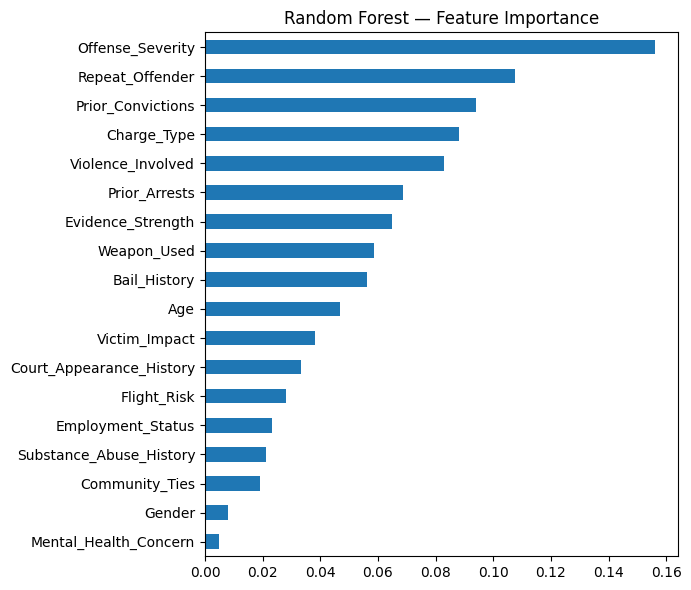

In [10]:
importances = pd.Series(rf_model.feature_importances_, index=feature_cols).sort_values()
plt.figure(figsize=(7, 6))
importances.plot(kind="barh")
plt.title("Random Forest — Feature Importance")
plt.tight_layout()
plt.show()

## 7. Model 3 — XGBoost Classifier

In [11]:
xgb_model = XGBClassifier(
    n_estimators=300, max_depth=6, learning_rate=0.1,
    eval_metric="mlogloss", random_state=RANDOM_STATE, n_jobs=-1
)
xgb_model.fit(X_train, y_train)

y_pred_xgb = xgb_model.predict(X_test)
xgb_accuracy = accuracy_score(y_test, y_pred_xgb)
print(f"XGBoost Accuracy: {xgb_accuracy:.3f}")
print(classification_report(y_test, y_pred_xgb, target_names=target_encoder.classes_))

XGBoost Accuracy: 0.763
              precision    recall  f1-score   support

        High       0.74      0.63      0.68      1500
         Low       0.85      0.88      0.87      5500
      Medium       0.61      0.62      0.61      3000

    accuracy                           0.76     10000
   macro avg       0.73      0.71      0.72     10000
weighted avg       0.76      0.76      0.76     10000



## 8. Confusion matrix for the Random Forest model

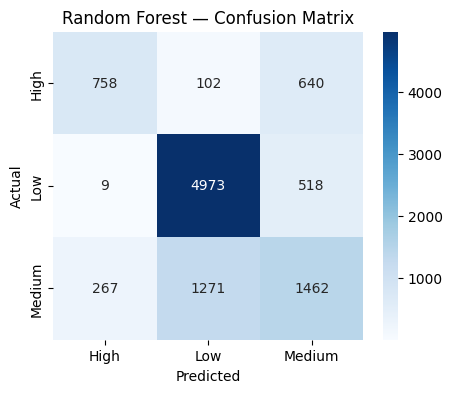

In [12]:
cm = confusion_matrix(y_test, y_pred_rf)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=target_encoder.classes_, yticklabels=target_encoder.classes_)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Random Forest — Confusion Matrix")
plt.show()

## 9. Model comparison & selection

Random Forest is used as the production model: it doesn't require feature scaling,
handles the mix of ordinal/categorical encodings well, and is the model consumed by
`bailmitra.ipynb` and the Flask inference API.

In [13]:
comparison = pd.DataFrame({
    "Model": ["Logistic Regression", "Random Forest", "XGBoost"],
    "Accuracy": [
        accuracy_score(y_test, y_pred_lr),
        rf_accuracy,
        xgb_accuracy,
    ],
}).sort_values("Accuracy", ascending=False)
comparison

,Model,Accuracy
2,XGBoost,0.7632
1,Random Forest,0.7193
0,Logistic Regression,0.6713


## 10. Sanity-check predictions on hand-crafted cases

In [14]:
def build_case(age, gender, prior_arrests, prior_convictions, offense_severity, charge_type,
               bail_history, flight_risk, employment_status, community_ties, weapon_used,
               violence_involved, evidence_strength, victim_impact, repeat_offender,
               substance_abuse_history, mental_health_concern, court_appearance_history):
    row = {
        "Age": age,
        "Gender": label_encoders["Gender"].transform([gender])[0],
        "Prior_Arrests": prior_arrests,
        "Prior_Convictions": prior_convictions,
        "Offense_Severity": label_encoders["Offense_Severity"].transform([offense_severity])[0],
        "Charge_Type": label_encoders["Charge_Type"].transform([charge_type])[0],
        "Bail_History": label_encoders["Bail_History"].transform([bail_history])[0],
        "Flight_Risk": label_encoders["Flight_Risk"].transform([flight_risk])[0],
        "Employment_Status": label_encoders["Employment_Status"].transform([employment_status])[0],
        "Community_Ties": label_encoders["Community_Ties"].transform([community_ties])[0],
        "Weapon_Used": label_encoders["Weapon_Used"].transform([weapon_used])[0],
        "Violence_Involved": label_encoders["Violence_Involved"].transform([violence_involved])[0],
        "Evidence_Strength": label_encoders["Evidence_Strength"].transform([evidence_strength])[0],
        "Victim_Impact": label_encoders["Victim_Impact"].transform([victim_impact])[0],
        "Repeat_Offender": label_encoders["Repeat_Offender"].transform([repeat_offender])[0],
        "Substance_Abuse_History": label_encoders["Substance_Abuse_History"].transform([substance_abuse_history])[0],
        "Mental_Health_Concern": label_encoders["Mental_Health_Concern"].transform([mental_health_concern])[0],
        "Court_Appearance_History": label_encoders["Court_Appearance_History"].transform([court_appearance_history])[0],
    }
    return pd.DataFrame([row])[feature_cols]

low_risk_case = build_case(
    age=45, gender="Female", prior_arrests=0, prior_convictions=0,
    offense_severity="Minor", charge_type="Petty Offense", bail_history="No Prior Bail",
    flight_risk="Low", employment_status="Employed", community_ties="Strong",
    weapon_used="No", violence_involved="No", evidence_strength="Weak",
    victim_impact="No Impact", repeat_offender="No", substance_abuse_history="No",
    mental_health_concern="No", court_appearance_history="Always Appeared",
)

high_risk_case = build_case(
    age=27, gender="Male", prior_arrests=8, prior_convictions=5,
    offense_severity="Severe", charge_type="Serious Felony", bail_history="Bail Violated",
    flight_risk="High", employment_status="Unemployed", community_ties="Weak",
    weapon_used="Yes", violence_involved="Yes", evidence_strength="Strong",
    victim_impact="Severe", repeat_offender="Yes", substance_abuse_history="Yes",
    mental_health_concern="Yes", court_appearance_history="Frequently Missed",
)

for name, case in [("Low-risk profile", low_risk_case), ("High-risk profile", high_risk_case)]:
    pred = rf_model.predict(case)[0]
    print(f"{name}: predicted Risk_Category = {target_encoder.inverse_transform([pred])[0]}")

Low-risk profile: predicted Risk_Category = Low
High-risk profile: predicted Risk_Category = High


## 11. Persist the production model

In [15]:
joblib.dump(rf_model, "risk_prediction_model.pkl")
joblib.dump(label_encoders, "feature_label_encoders.pkl")
joblib.dump(target_encoder, "risk_target_encoder.pkl")
print("Saved risk_prediction_model.pkl, feature_label_encoders.pkl, risk_target_encoder.pkl")

Saved risk_prediction_model.pkl, feature_label_encoders.pkl, risk_target_encoder.pkl


In [16]:
# Reload check
loaded_model = joblib.load("risk_prediction_model.pkl")
print(loaded_model.predict(high_risk_case))
print(loaded_model.predict(low_risk_case))

[0]
[1]


## 12. (Optional) Real-time inference API

The cell below defines a minimal Flask endpoint that wraps `risk_prediction_model.pkl`.
It is not executed automatically in this notebook — uncomment `app.run()` and run it as a
script (or in a separate process) to serve predictions.

In [17]:
# import joblib
# import pandas as pd
# from flask import Flask, request, jsonify
#
# model = joblib.load("risk_prediction_model.pkl")
# app = Flask(__name__)
#
# @app.route("/predict", methods=["POST"])
# def predict():
#     try:
#         data = request.get_json()
#         input_df = pd.DataFrame([data])[feature_cols]
#         prediction = model.predict(input_df)[0]
#         return jsonify({"Risk_Category": target_encoder.inverse_transform([prediction])[0]})
#     except Exception as e:
#         return jsonify({"error": str(e)}), 400
#
# if __name__ == "__main__":
#     app.run(debug=True)